# CÍL 6: ÚKOL – Segmentace medicínských snímků

> Tento notebook je součástí cvičení 12 předmětu BPC-PRG.  
> 📥 **[Stáhnout notebook (cviceni_12_segmentace.ipynb)](cviceni_12_segmentace.ipynb)** &nbsp;|&nbsp; 📥 **[Stáhnout data (cviceni_12_segmentace_data.zip)](../cviceni_12_segmentace_data.zip)**
>
> Po stažení ZIP rozbal vedle notebooku — vzniknou složky `skupina_a/` a `skupina_b/` se snímky.


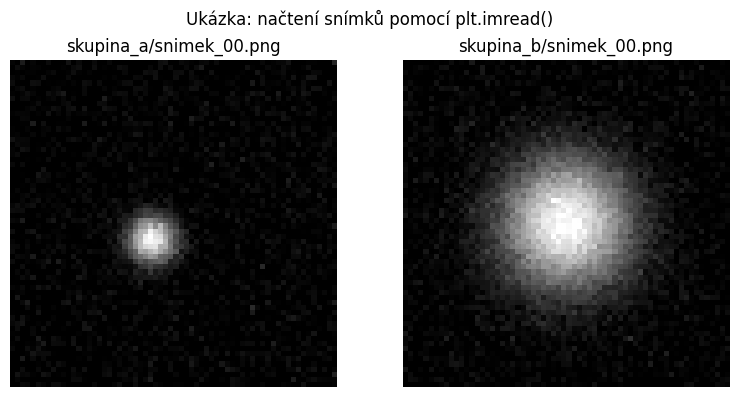

Tvar pole: (64, 64), hodnoty: min=0.000, max=1.000


In [14]:
# Ukázkové načtení a zobrazení dvou snímků pomocí pevně zadané cesty
# Spuštěním této buňky ověříš, že jsou soubory dostupné a funkce plt.imread() funguje
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

smmmek_am = plt.imread("skupina_a/snimek_00.png")[:, :, 0]
smmmek_bm = plt.imread("skupina_b/snimek_00.png")[:, :, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(smmmek_am, cmap="gray", vmin=0, vmax=1)
ax1.set_title("skupina_a/snimek_00.png")
ax1.axis("off")
ax2.imshow(smmmek_bm, cmap="gray", vmin=0, vmax=1)
ax2.set_title("skupina_b/snimek_00.png")
ax2.axis("off")
plt.suptitle("Ukázka: načtení snímků pomocí plt.imread()")
plt.tight_layout()
plt.show()
print(f"Tvar pole: {smmmek_am.shape}, hodnoty: min={smmmek_am.min():.3f}, max={smmmek_am.max():.3f}")


## Zadání

Máš k dispozici dvě skupiny simulovaných medicínských snímků ve složkách
`skupina_a/` a `skupina_b/` (5 snímků `.png` v každé složce):

- **`skupina_a/`** – „Zdravá tkáň": malý, kompaktní jasný region (~20 % plochy)
- **`skupina_b/`** – „Nádorová tkáň": velký, rozlitý jasný region (~45 % plochy)

Snímky načteš pomocí `plt.imread()`. Ten vrátí RGBA pole tvaru `(64, 64, 4)` –
pro práci s intenzitou stačí vzít první kanál: `snimek = plt.imread(...)[:, :, 0]`

Proveď postupně tyto kroky:

1. **Načti data** – načti všechny snímky ze složek a zobraz první snímek z každé skupiny.
2. **Prahování** – naprahuj jeden snímek, vytvoř binární masku a zobraz ji vedle originálu.
3. **Kvantitativní analýza** – spočítej poměrnou plochu pokrytou strukturou a průměrnou intenzitu uvnitř masky.
4. **Srovnání skupin** – zpracuj všechny snímky obou skupin a porovnej poměrné plochy boxplotem.


### Krok 1 – Načtení všech snímků

**Cíl:** Načíst všechny PNG snímky z obou složek do paměti jako NumPy pole a podívat se, jak vypadají.

**Jak na to:**

- Získej seznamy souborů ze složek: `sorted(glob.glob("skupina_a/*.png"))`.
- Každý snímek načti přes `plt.imread()`. Funkce vrátí RGBA pole tvaru `(64, 64, 4)` — bereme jen první kanál
  (intenzita): `plt.imread(cesta)[:, :, 0]`.
- Ulož obrázky do dvou seznamů `skupina_a` a `skupina_b`.

**Jak vizualizovat:**

- Pomocí `plt.subplots(1, 2)` zobraz první snímek každé skupiny vedle sebe.
- Na obou použij `ax.imshow(..., cmap="gray", vmin=0, vmax=1)` a popisný titulek (např. „Zdravá tkáň – snímek 0").
- `ax.axis("off")` skryje souřadnice, aby byl obrázek hezčí.

Počet snímků A: 5
Počet snímků B: 5
Tvar jednoho snímku: (64, 64)


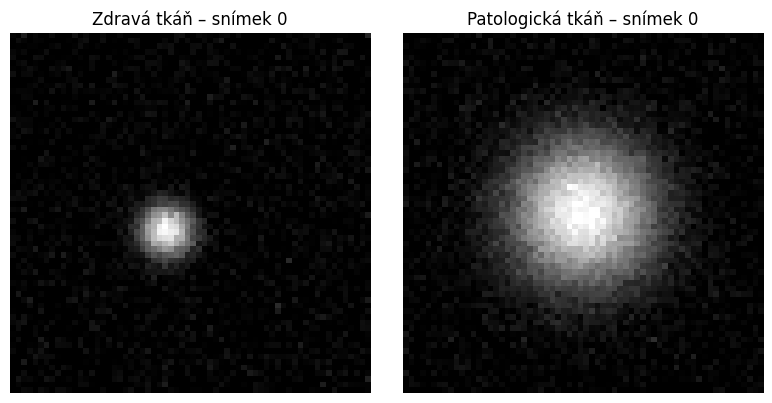

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# seznamy souborů
fileees_ae = sorted(glob.glob("skupina_a/*.png"))
fileees_be = sorted(glob.glob("skupina_b/*.png"))

# načtení obrázků (jen první kanál)
skupppp_ap = [plt.imread(f)[:, :, 0] for f in fileees_ae]
skupppp_bp = [plt.imread(f)[:, :, 0] for f in fileees_be]

print("Počet snímků A:", len(skupppp_ap))
print("Počet snímků B:", len(skupppp_bp))
print("Tvar jednoho snímku:", skupppp_ap[0].shape)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(skupppp_ap[0], cmap="gray", vmin=0, vmax=1)
ax[0].set_title("Zdravá tkáň – snímek 0")
ax[0].axis("off")

ax[1].imshow(skupppp_bp[0], cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Patologická tkáň – snímek 0")
ax[1].axis("off")

plt.tight_layout()
plt.show()

### Krok 2 – Prahování a vizualizace masky

**Cíl:** Pro jeden snímek vytvořit **binární masku** — pole typu `bool`, kde `True` znamená „tento pixel patří
do struktury".

**Jak na to:**

- Zvol práh, např. `PRAH = 0.5`. Pixely s intenzitou nad tuto hodnotu označíme jako součást struktury.
- Vyber jeden snímek (třeba `snimek = skupina_a[0]`).
- Masku vytvoříš jediným výrazem: `maska = snimek > PRAH` — NumPy vrátí pole `True`/`False` stejného tvaru.

**Jak vizualizovat:**

- Zobraz dva grafy vedle sebe:
    - **levý** – původní snímek s `cmap="gray"` a `vmin=0, vmax=1`,
    - **pravý** – binární maska s `cmap="gray"` (bílá/černá).
- Do titulku pravého grafu dej použitý práh, ať je hned vidět s jakým parametrem experimentuješ.

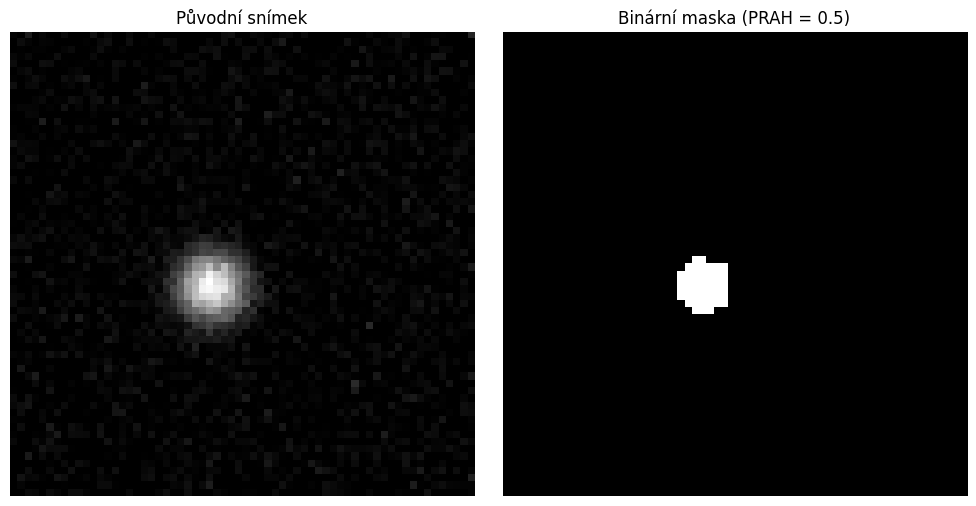

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# nastavení prahu
PRAH = 0.5

# výběr jednoho snímku
smmmek = skupppp_ap[0]

# vytvoření binární masky
masss = smmmek > PRAH

# vykreslení
plt.figure(figsize=(10, 5))

# původní snímek
plt.subplot(1, 2, 1)
plt.imshow(smmmek, cmap="gray", vmin=0, vmax=1)
plt.title("Původní snímek")
plt.axis("off")

# binární maska
plt.subplot(1, 2, 2)
plt.imshow(masss, cmap="gray")
plt.title(f"Binární maska (PRAH = {PRAH})")
plt.axis("off")

plt.tight_layout()
plt.show()

### Krok 3 – Kvantitativní analýza

**Cíl:** Pro snímek + masku z Kroku 2 spočítat dvě čísla:

1. **Poměrná plocha struktury** (v %) — jaký podíl obrazu tvoří pixely nad prahem.
2. **Průměrná intenzita** uvnitř struktury — průměr pixelů, pro které je maska `True`.

**Jak na to:**

- `maska.sum()` — NumPy sečte `True` (každé bere jako 1) → **počet pixelů ve struktuře**.
- `maska.size` — celkový počet pixelů v obraze (pro 64×64 je to 4096).
- `snimek[maska]` — NumPy boolean indexing: vrátí 1D pole s hodnotami tam, kde je maska `True`.

**Jak vizualizovat:** tady stačí `print()`. Čísla hrají roli, graf ne.

In [17]:
# počet pixelů ve struktuře
poccc_struktura = masss.sum()

# celkový počet pixelů
poccc_celkem = masss.size

# poměrná plocha v procentech
ploccc_procenta = (poccc_struktura / poccc_celkem) * 100

# průměrná intenzita uvnitř struktury
if poccc_struktura > 0:
    prumer_intenzita = smmmek[masss].mean()
else:
    prumer_intenzita = 0  # nebo np.nan, pokud chceš signalizovat "žádná data"

# výpis výsledků
print(f"Poměrná plocha struktury: {ploccc_procenta:.2f} %")
print(f"Průměrná intenzita ve struktuře: {prumer_intenzita:.3f}")

Poměrná plocha struktury: 1.10 %
Průměrná intenzita ve struktuře: 0.714


### Krok 4 – Srovnání skupin: boxplot

**Cíl:** Aplikovat stejné prahování na **všech 10 snímků** (5 v každé skupině), získat pro každý poměrnou
plochu a výsledky porovnat boxplotem.

**Jak na to:**

- Pro každou skupinu projdi všechny snímky a spočítej poměrnou plochu při `PRAH = 0.5`.
- Výsledky ulož do dvou seznamů: `podily_a`, `podily_b`.
- Je fajn si definovat malou funkci `spocitej_podil(snimek, prah)` — ať se neopakuješ.

**Jak vizualizovat:**

- `ax.boxplot([podily_a, podily_b], tick_labels=["Zdravá tkáň", "Nádorová tkáň"])`.
- Popiš osu Y (`"Plocha struktury (%)"`), přidej titulek.
- `ax.grid(True, axis="y", alpha=0.4)` zlepší čitelnost mřížky.

**Co bys měl vidět:** „nádorová" skupina má výrazně větší plochu pokrytou strukturou (~45 %) než skupina
zdravá (~20 %) — boxy by měly být zřetelně oddělené.

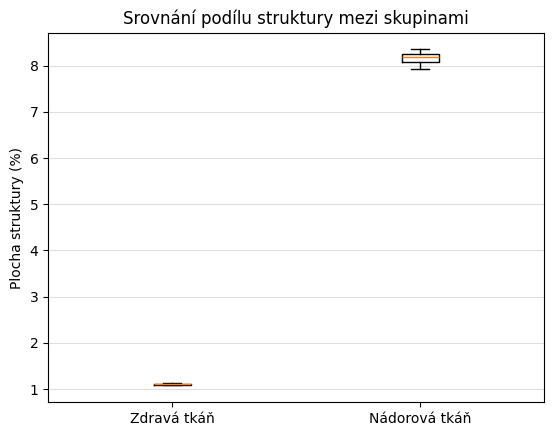

In [19]:
import numpy as np
import matplotlib.pyplot as plt

PRAH = 0.5

# funkce pro výpočet podílu struktury
def spocitej_podil(smmmek, prah):
    masss = smmmek > prah
    poccc_struktura = masss.sum()
    poccc_celkem = masss.size
    ploccc_procenta = (poccc_struktura / poccc_celkem) * 100
    return ploccc_procenta


# výpočet pro skupinu A
podily_a = []
for smmmek in skupppp_ap:
    podily_a.append(spocitej_podil(smmmek, PRAH))

# výpočet pro skupinu B
podily_b = []
for smmmek in skupppp_bp:
    podily_b.append(spocitej_podil(smmmek, PRAH))


# boxplot
fig, ax = plt.subplots()

ax.boxplot([podily_a, podily_b], tick_labels=["Zdravá tkáň", "Nádorová tkáň"])

ax.set_ylabel("Plocha struktury (%)")
ax.set_title("Srovnání podílu struktury mezi skupinami")
ax.grid(True, axis="y", alpha=0.4)

plt.show()

### Interpretace

Krátce komentuj:

- Jak se skupiny liší v poměrné ploše struktury?
- Dá se rozdíl pozorovat pouhým okem i z původních snímků (Krok 1), nebo je potřeba kvantitativní analýzy?
- Co by v reálné situaci mohlo narušit tuto jednoduchou metodu (např. šum, různá intenzita osvětlení,
  artefakty)? Jak by se dalo postupovat dál?

*Sem napiš svou odpověď.*